#### Model Comparison

В данном ноутбуке производится обучение и сравнение нескольких моделей с целью определения лучшей для решения задачи.

In [24]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, 
    mean_absolute_percentage_error, 
    mean_squared_error, 
    r2_score,
)

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from pathlib import Path

sys.path.append(str(Path().resolve().parent))
from src.utils import get_project_root
from src.preprocessing import preprocess_dataset
from src.splitting import split_dataset

In [25]:
PROJECT_ROOT = get_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw"
ARTIFACTS_ROOT = PROJECT_ROOT / "artifacts" / "experiments"

In [26]:
raw_df = pd.read_csv(DATA_PATH/"train.csv")

raw_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [27]:
df = preprocess_dataset(raw_df)

df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,month,year,hour_sin,hour_cos,weekday_sin,weekday_cos,count
0,1,0,0,1,9.84,14.395,81,0.0,1,2011,0.000000,1.000000,-0.974928,-0.222521,16
1,1,0,0,1,9.02,13.635,80,0.0,1,2011,0.258819,0.965926,-0.974928,-0.222521,40
2,1,0,0,1,9.02,13.635,80,0.0,1,2011,0.500000,0.866025,-0.974928,-0.222521,32
3,1,0,0,1,9.84,14.395,75,0.0,1,2011,0.707107,0.707107,-0.974928,-0.222521,13
4,1,0,0,1,9.84,14.395,75,0.0,1,2011,0.866025,0.500000,-0.974928,-0.222521,1


In [28]:
X_train, X_test, y_train, y_test = split_dataset(df, test_size=0.2)

In [29]:
print("Размеры выборок")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Размеры выборок
X_train: (8708, 14)
y_train: (8708,)
X_test: (2178, 14)
y_test: (2178,)


#### Эксперимент 1 - сравнение нескольких моделей

In [30]:
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),

    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    ),
}

In [31]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        "train_MAE": mean_absolute_error(y_train, y_train_pred),
        "test_MAE": mean_absolute_error(y_test, y_test_pred),

        "train_RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred,)),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),

        "train_R2": r2_score(y_train, y_train_pred),
        "test_R2": r2_score(y_test, y_test_pred),

        "train_MAPE": mean_absolute_percentage_error(y_train, y_train_pred),
        "test_MAPE": mean_absolute_percentage_error(y_test, y_test_pred),
    }

    return metrics

In [32]:
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")

    metrics = evaluate_model(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )

    metrics["model"] = model_name
    results.append(metrics)

Training DummyRegressor...
Training LinearRegression...
Training Ridge...
Training RandomForest...
Training LightGBM...
Training CatBoost...


In [33]:
experiment_1_results_df = pd.DataFrame(results)

experiment_1_results_df = experiment_1_results_df[
    [
        "model",
        "train_MAE",
        "test_MAE",
        "train_RMSE",
        "test_RMSE",
        "train_R2",
        "test_R2",
        "train_MAPE",
        "test_MAPE",
    ]
]

experiment_1_results_df = experiment_1_results_df.sort_values("test_RMSE", ignore_index=True)

Для оценки моделей используются несколько метрик, поскольку каждая из них отражает различные аспекты качества прогнозирования.
- RMSE - среднеквадратическая ошибка, показывает насколько модель ошибается в тех же единицах, что и таргет. Она использовалась как основная, потому что сильнее штрафует за ошибки. Это особенно важно для задачи прогнозирования спроса, так как большие ошибки могут приводить к нехватке или переизбытку ресурсов.
- MAE - средняя абсолютная ошибка. Она показывает типичную ошибку в единицах измерения таргета, что делает ее легко интерпретируемой.
- R2 - коэффициент детерминации. Позволяет оценить обобщающую способность модели. Используется как дополнительная характеристика качества
- MAPE - средняя абсолютная процентная ошибка. Показывает, на сколько в среднем модель ошибается в процентах по отношению к реальным значениям. Однако при наличии очень малых значений таргета метрика может быть нестабильной, в данном случае она используется как вспомогательная.

In [34]:
experiment_1_results_df.to_csv(ARTIFACTS_ROOT/"exp01_model_comparison.csv", index=False)

experiment_1_results_df

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,train_MAPE,test_MAPE
0,CatBoost,20.034517,38.370407,30.276555,57.838021,0.966905,0.929348,0.407690,0.455402
1,LightGBM,17.803528,38.285515,26.959234,57.957747,0.973760,0.929056,0.364414,0.412373
2,RandomForest,8.359316,45.711063,13.801419,70.896639,0.993123,0.893844,0.110738,0.263028
3,Ridge,85.191533,124.748081,116.966209,164.961395,0.506069,0.425276,2.747333,2.858354
4,LinearRegression,85.194190,124.759097,116.966182,164.974851,0.506069,0.425182,2.747943,2.858220
5,DummyRegressor,130.715168,176.581536,166.428328,233.932186,0.000000,-0.155779,7.972492,3.988692


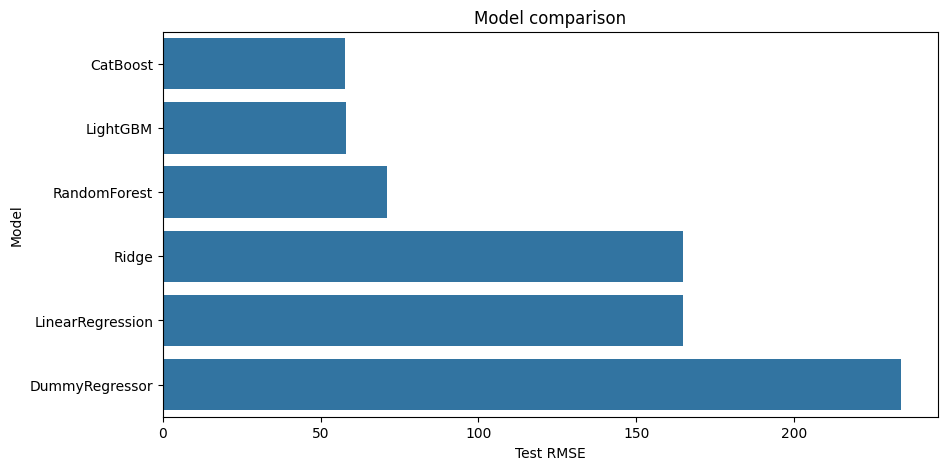

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=experiment_1_results_df,
    x="test_RMSE",
    y="model"
)

plt.title("Model comparison")
plt.xlabel("Test RMSE")
plt.ylabel("Model")

plt.savefig(ARTIFACTS_ROOT/"exp01_model_comparison.png")
plt.show()

#### Итоги первого эксперимента

Все ML-модели существенно превзошли бейзлайн, который просто считал среднее значение таргета, что свидетельствует об информативности признаков и корректности preprocessing pipeline.

Линейные модели Ridge и LinearRegression показали значительно более слабые результаты относительно ансамблевых моделей даже при масштабировании признаков. Это объясняется тем, что задача содержит сложные нелинейные зависимости и имеет temporal характер данных.

Ансамблевые модели показали лучшие результаты, это неудивительно, ведь они способны находить сложные нелинейные зависимости. Однако RandomForest имеет выраженное переобучение, т.к. метрики на тестовых данных существенно хуже, чем на тренировочных.

LightGBM и CatBoost продемонстрировали практически одинаковое качество на тестовой выборке и значительно превзошли остальные модели. Поэтому именно они были выбраны для дальнейшего улучшения и сравнения.

#### Эксперимент 2 - сравнение разумных ручных конфигураций LightGBM и CatBoost

In [36]:
candidate_models = {
    "LightGBM_base": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),

    "LightGBM_slow": LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),

    "LightGBM_regularized": LGBMRegressor(
        n_estimators=700,
        learning_rate=0.04,
        max_depth=5,
        reg_alpha=0.1,
        reg_lambda=0.5,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),

    "CatBoost_base": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    ),

    "CatBoost_slow": CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    ),

    "CatBoost_regularized": CatBoostRegressor(
        iterations=700,
        learning_rate=0.04,
        depth=5,
        l2_leaf_reg=7,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
    ),
}

In [37]:
experiment_2_results = []

for model_name, model in candidate_models.items():
    print(f"Training {model_name}...")

    metrics = evaluate_model(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )

    metrics["model"] = model_name
    experiment_2_results.append(metrics)

Training LightGBM_base...
Training LightGBM_slow...
Training LightGBM_regularized...
Training CatBoost_base...
Training CatBoost_slow...
Training CatBoost_regularized...


In [38]:
experiment_2_results_df = pd.DataFrame(experiment_2_results)

experiment_2_results_df = experiment_2_results_df[
    [
        "model",
        "train_MAE",
        "test_MAE",
        "train_RMSE",
        "test_RMSE",
        "train_R2",
        "test_R2",
        "train_MAPE",
        "test_MAPE",
    ]
]

experiment_2_results_df = experiment_2_results_df.sort_values("test_RMSE")
experiment_2_results_df.to_csv(ARTIFACTS_ROOT/"exp02_LightGBM_vs_CatBoost_configurations.csv",index=False)

experiment_2_results_df

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,train_MAPE,test_MAPE
1,LightGBM_slow,16.837131,36.863553,25.292486,56.257946,0.976904,0.933156,0.347925,0.382221
4,CatBoost_slow,19.154533,37.366382,28.976756,56.630806,0.969686,0.932267,0.384657,0.433141
2,LightGBM_regularized,18.996209,38.055716,28.752810,57.315940,0.970153,0.930618,0.396715,0.467873
3,CatBoost_base,20.034517,38.370407,30.276555,57.838021,0.966905,0.929348,0.407690,0.455402
0,LightGBM_base,17.803528,38.285515,26.959234,57.957747,0.973760,0.929056,0.364414,0.412373
5,CatBoost_regularized,23.048269,40.888027,34.652182,60.887799,0.956648,0.921701,0.515457,0.473798


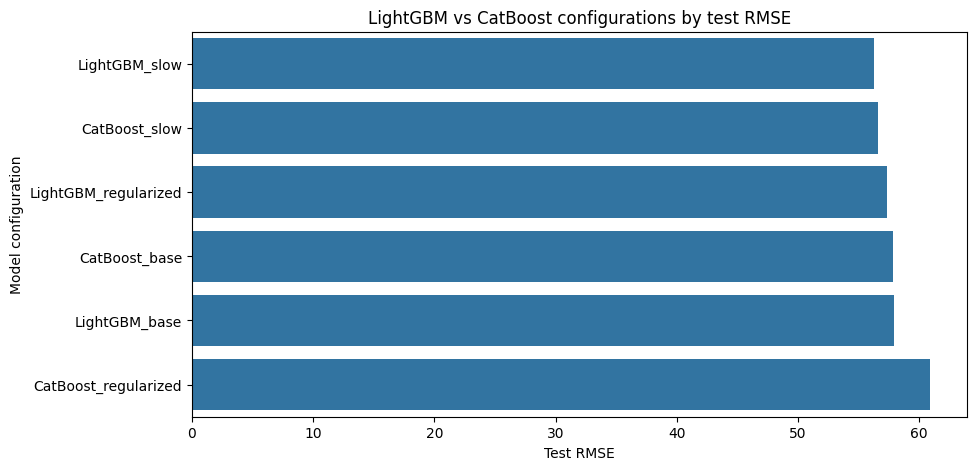

In [39]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=experiment_2_results_df,
    x="test_RMSE",
    y="model",
)

plt.title("LightGBM vs CatBoost configurations by test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model configuration")

plt.savefig(ARTIFACTS_ROOT/"exp02_LightGBM_vs_Catboost_configurations.png")
plt.show()

#### Итоги второго эксперимента

Во втором эксперименте были рассмотрены несколько конфигураций моделей LightGBM и CatBoost. Целью эксперимента было определить оценку устойчивости моделей к изменению параметров и выявить более перспективную модель для дальнейшего улучшения.

Результаты показали, что для обеих моделей уменьшение learning rate с одновременным увеличением количества деревьев дало прирост качества по сравнению с базовыми конфигурациями. При этом усиление регуляризации дало потерю в качестве, что свидетельствует об отсутствии явно выраженного переобучения.

Лучшие результаты показали конфигурации LightGBM_slow и CatBoost_slow. Разница между ними оказалась незначительной, а обе модели продемонстрировали схожие значения всех основных метрик качества.

Таким образом, результаты эксперимента не позволяют однозначно определить лучшую модель. Для принятия окончательного решения требуется дополнительное сравнение моделей с использованием более детального подбора гиперпараметров.

#### Эксперимент 3 - небольшой подбор гиперпараметров для LightGBM и CatBoost

In [40]:
cv=TimeSeriesSplit(n_splits=3)

In [41]:
lgbm = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

catboost = CatBoostRegressor(
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)

In [42]:
lgbm_params = {
    "n_estimators": [700, 1000, 1200],
    "learning_rate": [0.02, 0.03, 0.04],
    "max_depth": [5, 6, 7],
    "num_leaves": [31, 50],
    "min_child_samples": [20, 40],
}

catboost_params = {
    "iterations": [700, 1000, 1200],
    "learning_rate": [0.02, 0.03, 0.04],
    "depth": [5, 6, 7],
    "l2_leaf_reg": [3, 5, 7],
}

In [43]:
lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_params,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

catboost_search = RandomizedSearchCV(
    estimator=catboost,
    param_distributions=catboost_params,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

In [44]:
lgbm_search.fit(X_train, y_train)
catboost_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CatBoostRegre...verbose=False)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': [5, 6, ...], 'iterations': [700, 1000, ...], 'l2_leaf_reg': [3, 5, ...], 'learning_rate': [0.02, 0.03, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [45]:
print("Best LightGBM params:")
print(lgbm_search.best_params_)
print("Best LightGBM CV RMSE:", -lgbm_search.best_score_)
print("=" * 100)
print("Best CatBoost params:")
print(catboost_search.best_params_)
print("Best CatBoost CV RMSE:", -catboost_search.best_score_)

Best LightGBM params:
{'num_leaves': 31, 'n_estimators': 1000, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.02}
Best LightGBM CV RMSE: 79.00771004848247
Best CatBoost params:
{'learning_rate': 0.03, 'l2_leaf_reg': 3, 'iterations': 1000, 'depth': 5}
Best CatBoost CV RMSE: 82.21853708741033


In [46]:
best_lgbm = lgbm_search.best_estimator_
best_catboost = catboost_search.best_estimator_

In [47]:
experiment_3_results = []

experiment_3_models = {
    "LightGBM_random_search": best_lgbm,
    "CatBoost_random_search": best_catboost,
}
for model_name, model in experiment_3_models.items():
    metrics = evaluate_model(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
    )

    metrics["model"] = model_name
    experiment_3_results.append(metrics)

In [48]:
experiment_3_results_df = pd.DataFrame(experiment_3_results)

experiment_3_results_df = experiment_3_results_df[
    [
        "model",
        "train_MAE",
        "test_MAE",
        "train_RMSE",
        "test_RMSE",
        "train_R2",
        "test_R2",
        "train_MAPE",
        "test_MAPE",
    ]
]

experiment_3_results_df = experiment_3_results_df.sort_values("test_RMSE")
experiment_3_results_df.to_csv(ARTIFACTS_ROOT/"exp03_RandomizedSearchCV_LightGBM_vs_CatBoost.csv", index=False)

experiment_3_results_df

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,train_MAPE,test_MAPE
0,LightGBM_random_search,17.271214,36.165671,26.083985,55.279079,0.975436,0.935462,0.353441,0.367997
1,CatBoost_random_search,22.192121,40.167201,33.241266,60.173361,0.960107,0.923528,0.511707,0.479708


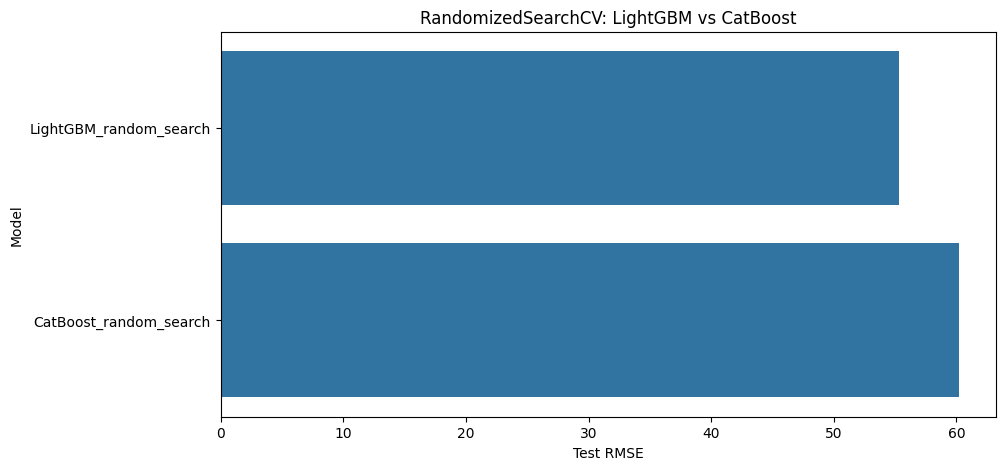

In [49]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=experiment_3_results_df,
    x="test_RMSE",
    y="model",
)

plt.title("RandomizedSearchCV: LightGBM vs CatBoost")
plt.xlabel("Test RMSE")
plt.ylabel("Model")

plt.savefig(ARTIFACTS_ROOT/"exp03_RandomizedSearchCV_LightGBM_vs_CatBoost.png")
plt.show()

#### Итоги третьего эксперимента

В третьем эксперименте был проведен ограниченный подбор гиперпараметров для моделей LightGBM и CatBoost с помощью RandomizedSearchCV и TimeSeriesSplit. Целью эксперимента являлось окончательно выявить более перспективную модель для последующего улучшения.

Результаты эксперимента показали, что после подбора гиперпараметров модель LightGBM улучшила качество прогнозирования относительно лучших конфигураций предыдущих экспериментов и продемонстрировала наилучшие значения RMSE, MAE и R2 на тестовой выборке.

Для CatBoost подбор гиперпараметров не дал прироста в качестве. Наоборот, модель показала более слабое качество по сравнению с конфигурациями предыдущих экспериментов.

Таким образом, результаты эксперимента свидетельствуют о том, что LightGBM обладает самым высоким потенциалом дальнейшего улучшения под имеющуюся задачу.